# Real-LLM Matched-Coverage Closure Showdown on the Synthetic QCN Backbone

**Artifact `art_N0e4pH_C_Cxw` — experiment `experiment_iter2_dir3` (tag `REAL-LLM-READ-ON-SYNTHETIC`).**

This demo reproduces the **core symbolic engine** and the **matched-coverage selective-accuracy
showdown** of the paper, offline and for free.

### What the experiment does
A real OpenRouter LLM (`google/gemini-3.1-flash-lite`, temp 0) makes **local, disjunctive reads**
of natural-language realizations of a synthetic *qualitative constraint network* (QCN) backbone.
Those reads feed a validated **Mackworth PC-2 path-consistency closure engine**. Every baseline is
compared at **matched single-relation coverage** over the *same* networks.

* **Our method — Mode-A** = iterated path-consistency closure. It *answers* a deduction-required
  query pair `(s,t)` **iff** closure narrows it to a singleton (else it **abstains**); an
  empty-collapse is a **Mode-B** inconsistency certificate.
* **Baselines:** naive single-pass (iteration contrast), OFF (coverage 0), raw LLM,
  chain-of-thought, self-consistency K=5, LINC, **Path-of-Thoughts (PoT)**, ILP-commit.

### Central finding
The closure advantage over neural per-path reasoning **scales with relation-algebra richness**:
on the simple **3-relation point algebra** the LLM already composes well (small gap), but on the
rich **13-relation Allen interval algebra** neural chaining collapses while symbolic closure stays
robust (large gap).

### How this demo stays free & fast
The expensive part (real LLM reads, ~$2 / 24 938 calls) is **not** re-run. Instead we:
1. run the **exact closure engine** (`engine.py`, copied verbatim) live on real worked-example
   traces and clean hand-built networks, and
2. recompute the **selective-accuracy showdown** from the **cached real-LLM predictions** stored in
   `mini_demo_data.json`.

We also print the **precomputed full-run headline** (2520 networks) for reference.

In [1]:
# Dependencies. On Colab the core scientific stack is pre-installed (do NOT reinstall it
# or the loaded C extensions corrupt); locally we install Colab's exact versions.
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy / matplotlib are pre-installed on Colab -> install locally only.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- imports (engine.py's own imports + notebook extras) ---
from __future__ import annotations
import itertools
from collections import deque, defaultdict
import json, os
import numpy as np
import matplotlib.pyplot as plt

SEED = 20260617

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-2/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print()
print("worked_examples algebras :", list(data["worked_examples"].keys()))
print("networks per algebra     :", {k: len(v) for k, v in data["networks"].items()})
print("headline algebras        :", list(data["headline"]["by_algebra"].keys()))

Curated demo subset of the Real-LLM Matched-Coverage Closure Showdown (experiment_iter2_dir3). worked_examples = real sentence->LLM-read->gold->closure traces; networks = cached real-LLM predictions per method for the selective-accuracy showdown; headline = the full-run (2520 networks) results.

worked_examples algebras : ['point', 'allen']
networks per algebra     : {'point': 50, 'allen': 50}
headline algebras        : ['point', 'allen']


## Configuration

All tunable knobs live here. The demo is pure-CPU symbolic computation plus a small bootstrap, so
it runs in seconds. Start small; scale `BOOTSTRAP_B` / `DEMO_NETS_PER_ALGEBRA` if you want tighter
confidence intervals.

In [5]:
# --- demo config ---
DEMO_NETS_PER_ALGEBRA = 50   # networks used from the cached subset (full subset = 50/algebra)
BOOTSTRAP_B           = 500  # paired-bootstrap resamples for the gap CI (full run used 2000)
ALPHA                 = 0.05 # CI level
# Original full run: 2520 networks (90 nets/cell x 14 cells x 2 algebras), bootstrap B=2000.

## 1. The closure engine — relation algebras (copied verbatim from `engine.py`)

Two qualitative calculi are built **programmatically** (no external tables):

* **POINT** — convex point algebra over event start-points `{<, =, >}`. Path-consistency (PC) is
  **complete** here (exact). The only non-convex relation `{<,>}` is *widened* to the universe to
  keep PC complete.
* **ALLEN** — the 13-relation interval algebra. Its base×base composition table is generated by the
  **endpoint method** (enumerate weak orders of the six interval endpoints). Full Allen PC is sound
  but a **lower bound** for inconsistency.

In [6]:
# ----------------------------------------------------------------------------------
# Allen-13 base relations (qualreas-compatible symbols) and their endpoint geometry.
# Interval X = (Xs, Xe) with Xs < Xe. relation(X, Y) defined on (Xs, Xe, Ys, Ye).
# ----------------------------------------------------------------------------------
ALLEN_BASE = ["B", "BI", "D", "DI", "O", "OI", "M", "MI", "S", "SI", "F", "FI", "E"]
ALLEN_CONVERSE = {"B": "BI", "BI": "B", "D": "DI", "DI": "D", "O": "OI", "OI": "O",
                  "M": "MI", "MI": "M", "S": "SI", "SI": "S", "F": "FI", "FI": "F", "E": "E"}


def _allen_rel(xs: int, xe: int, ys: int, ye: int):
    """Atomic Allen relation of interval X=(xs,xe) to Y=(ys,ye) from endpoint ranks."""
    if not (xs < xe and ys < ye):
        return None
    if xs == ys and xe == ye:
        return "E"
    if xe < ys:
        return "B"
    if ye < xs:
        return "BI"
    if xe == ys:
        return "M"
    if ye == xs:
        return "MI"
    if xs == ys:
        return "S" if xe < ye else "SI"
    if xe == ye:
        return "F" if xs > ys else "FI"
    if xs < ys and ye < xe:
        return "DI"
    if ys < xs and xe < ye:
        return "D"
    if xs < ys < xe < ye:
        return "O"
    if ys < xs < ye < xe:
        return "OI"
    return None  # unreachable for proper intervals


def _build_allen_compose():
    """Generate the Allen base x base composition table via endpoint enumeration."""
    comp = {(a, b): set() for a in ALLEN_BASE for b in ALLEN_BASE}
    for asg in itertools.product(range(6), repeat=6):
        As, Ae, Bs, Be, Cs, Ce = asg
        if not (As < Ae and Bs < Be and Cs < Ce):
            continue
        rab = _allen_rel(As, Ae, Bs, Be)
        rbc = _allen_rel(Bs, Be, Cs, Ce)
        rac = _allen_rel(As, Ae, Cs, Ce)
        if rab is None or rbc is None or rac is None:
            continue
        comp[(rab, rbc)].add(rac)
    return {k: frozenset(v) for k, v in comp.items()}


# ----------------------------------------------------------------------------------
# Point algebra over start-points.
# ----------------------------------------------------------------------------------
POINT_BASE = ["<", "=", ">"]
POINT_CONVERSE = {"<": ">", "=": "=", ">": "<"}
# GQR point.comp (verified): = is identity; <o<={<}; >o>={>}; <o>=>o<=universal.
POINT_COMPOSE = {
    ("=", "="): frozenset({"="}),
    ("<", "="): frozenset({"<"}), ("=", "<"): frozenset({"<"}),
    (">", "="): frozenset({">"}), ("=", ">"): frozenset({">"}),
    ("<", "<"): frozenset({"<"}),
    (">", ">"): frozenset({">"}),
    ("<", ">"): frozenset({"<", "=", ">"}),
    (">", "<"): frozenset({"<", "=", ">"}),
}
POINT_NONCONVEX = frozenset({"<", ">"})  # the only non-convex point relation (`!=`)


class Algebra:
    """A qualitative calculus with relation sets stored as frozensets of base symbols."""

    def __init__(self, name, base, converse, compose_bb, identity, convex_widen=None):
        self.name = name
        self.base = list(base)
        self.universe = frozenset(base)
        self.empty = frozenset()
        self.identity = frozenset(identity)
        self._conv = dict(converse)
        self._comp = dict(compose_bb)
        # `convex_widen` (point only): the unique non-convex relation widened to the
        # universal set to keep PC complete. None => no widening.
        self._nonconvex = convex_widen

    def converse(self, s):
        return frozenset(self._conv[r] for r in s)

    def compose(self, a, b):
        if not a or not b:
            return self.empty
        out = set()
        for x in a:
            for y in b:
                out |= self._comp[(x, y)]
        return frozenset(out)

    def is_nonconvex(self, s):
        return self._nonconvex is not None and s == self._nonconvex

    def widen(self, s):
        """Return (possibly-widened set, fired?)."""
        if self._nonconvex is not None and s == self._nonconvex:
            return self.universe, True
        return s, False

    def label(self, s):
        if not s:
            return "EMPTY"
        if s == self.universe:
            return "UNIVERSE"
        return "|".join(r for r in self.base if r in s)


def build_point_algebra():
    return Algebra("POINT", POINT_BASE, POINT_CONVERSE, POINT_COMPOSE,
                   frozenset({"="}), convex_widen=POINT_NONCONVEX)


def build_allen_algebra():
    return Algebra("ALLEN", ALLEN_BASE, ALLEN_CONVERSE, _build_allen_compose(),
                   frozenset({"E"}), convex_widen=None)

## 2. The closure engine — QCN + PC-2 (copied verbatim from `engine.py`)

A `QCN` is a constraint network: a dense node list with each edge a frozenset of base symbols
(missing edge ⇒ universe). The two closure operators are:

* **`pc2_full`** (OUR METHOD) — Mackworth **PC-2** worklist closure to fixpoint. An empty edge ⇒
  inconsistent (a **Mode-B** certificate).
* **`naive_single_pass`** — a single pass of length-2 path intersections at the query edge, with
  **no fixpoint / no re-propagation** (the iteration-isolation baseline).

In [7]:
class QCN:
    """Constraint network: dense node list, edges = relation-set frozensets.

    Missing edge => universe. Invariants on set_edge: M[j][i]==converse(M[i][j]),
    M[i][i]==identity.
    """

    def __init__(self, alg, nodes):
        self.alg = alg
        self.nodes = list(nodes)
        self.n = len(self.nodes)
        self.index = {nd: i for i, nd in enumerate(self.nodes)}
        U = alg.universe
        self.M = [[U] * self.n for _ in range(self.n)]
        for i in range(self.n):
            self.M[i][i] = alg.identity
        self.nbrs = [set() for _ in range(self.n)]

    def set_edge(self, i, j, s):
        if i == j:
            return
        self.M[i][j] = s
        self.M[j][i] = self.alg.converse(s)
        if s != self.alg.universe:
            self.nbrs[i].add(j); self.nbrs[j].add(i)
        else:
            self.nbrs[i].discard(j); self.nbrs[j].discard(i)

    def get(self, i, j):
        return self.M[i][j]

    def known_edges(self):
        U = self.alg.universe
        return [(i, j) for i in range(self.n) for j in range(i + 1, self.n) if self.M[i][j] != U]


def pc2_full(qcn):
    """OUR METHOD: Mackworth PC-2 worklist closure to fixpoint.

    Returns (consistent: bool, n_fired). Empty edge => inconsistent (Mode-B certificate).
    """
    alg = qcn.alg
    U = alg.universe
    M = qcn.M
    nbrs = qcn.nbrs
    Q = deque()
    inq = set()
    for (i, j) in qcn.known_edges():
        Q.append((i, j)); inq.add((i, j))
        Q.append((j, i)); inq.add((j, i))
    n_fired = 0

    def enqueue(a, b):
        if (a, b) not in inq:
            inq.add((a, b)); Q.append((a, b))

    while Q:
        i, j = Q.popleft(); inq.discard((i, j))
        rij = M[i][j]
        if rij == U:
            continue
        for k in list(nbrs[j]):
            if k == i:
                continue
            comp = alg.compose(rij, M[j][k])
            new = M[i][k] & comp
            new, _ = alg.widen(new)
            if new != M[i][k]:
                if not new:
                    return False, n_fired
                M[i][k] = new; M[k][i] = alg.converse(new)
                nbrs[i].add(k); nbrs[k].add(i)
                n_fired += 1
                enqueue(i, k); enqueue(k, i)
        for k in list(nbrs[i]):
            if k == j:
                continue
            comp = alg.compose(M[k][i], rij)
            new = M[k][j] & comp
            new, _ = alg.widen(new)
            if new != M[k][j]:
                if not new:
                    return False, n_fired
                M[k][j] = new; M[j][k] = alg.converse(new)
                nbrs[k].add(j); nbrs[j].add(k)
                n_fired += 1
                enqueue(k, j); enqueue(j, k)
    return True, n_fired


def naive_single_pass(qcn, u, v):
    """BASELINE: single pass of length-2 path compositions at the query edge (u,v).

    NO fixpoint, NO re-propagation.
    """
    alg = qcn.alg
    U = alg.universe
    M = qcn.M
    R = U
    for w in qcn.nbrs[u]:
        if w in (u, v):
            continue
        if M[w][v] != U:
            R = R & alg.compose(M[u][w], M[w][v])
            R, _ = alg.widen(R)
            if not R:
                return alg.empty
    return R

### Sanity check: composition spot-prints

Reproduces the spot-checks from `engine.py`'s `__main__`. (`B∘B = B`: before-then-before is
before; `D∘DI` blows up to a large disjunction; the point `<∘>` is the full universe.)

In [8]:
POINT = build_point_algebra()
ALLEN = build_allen_algebra()
print("POINT base:", POINT.base)
print("ALLEN base:", ALLEN.base, "| n compose cells:", len(ALLEN._comp))
print("ALLEN  B o B  =", sorted(ALLEN.compose(frozenset({'B'}), frozenset({'B'}))))
print("ALLEN  D o DI =", sorted(ALLEN.compose(frozenset({'D'}), frozenset({'DI'}))))
print("POINT  < o >  =", sorted(POINT.compose(frozenset({'<'}), frozenset({'>'}))))

POINT base: ['<', '=', '>']
ALLEN base: ['B', 'BI', 'D', 'DI', 'O', 'OI', 'M', 'MI', 'S', 'SI', 'F', 'FI', 'E'] | n compose cells: 169
ALLEN  B o B  = ['B']
ALLEN  D o DI = ['B', 'BI', 'D', 'DI', 'E', 'F', 'FI', 'M', 'MI', 'O', 'OI', 'S', 'SI']
POINT  < o >  = ['<', '=', '>']


## 3. Mode-A closure on a **real** worked example (point algebra)

Below is an actual trace recorded by the full pipeline: a document about scheduled corporate events,
the LLM's **local disjunctive reads** of each sentence, the **gold** atomic relations, and the
deduction-required query. We rebuild the QCN from these reads and run the **exact** `pc2_full`
closure — Mode-A answers iff the query edge narrows to a **singleton**.

In [9]:
ALG = {"point": POINT, "allen": ALLEN}

def build_qcn_from_reads(alg, reads, query_pair):
    """Mirror method.py's build_qcn: set each non-query gold edge to its directed LLM read."""
    nodes = set(query_pair)
    for r in reads:
        nodes.update(r["edge"])
    q = QCN(alg, list(range(max(nodes) + 1)))
    s, t = query_pair
    for r in reads:
        a, b = r["edge"]
        if {a, b} == {s, t}:
            continue
        if r["read"]:                       # non-empty read; empty => leave at universe
            q.set_edge(a, b, frozenset(r["read"]))
    return q

def run_mode_a(alg, trace):
    """method.py mode_a: full PC closure, answer iff query edge is a singleton."""
    s, t = trace["query_pair"]
    q = build_qcn_from_reads(alg, trace["reads"], (s, t))
    consistent, n_fired = pc2_full(q)
    if not consistent:
        return {"covered": False, "answer": None, "mode_b": True, "query_set": [], "n_fired": n_fired}
    rq = q.get(s, t)
    return {"covered": len(rq) == 1, "answer": (next(iter(rq)) if len(rq) == 1 else None),
            "mode_b": False, "query_set": sorted(rq), "n_fired": n_fired}

def show_trace(alg, trace, title):
    print(f"### {title}  [{trace['net_id']}]")
    print(f"Query: relation between {trace['query_entities'][0]!r} and "
          f"{trace['query_entities'][1]!r}   (gold = {trace['gold_query']})")
    print("Local sentence reads:")
    for r in trace["reads"]:
        print(f"  edge {tuple(r['edge'])}: read={r['read']} gold=[{r['gold']}]  | {r['sentence']}")
    res = run_mode_a(alg, trace)
    print(f"-> closure narrowed query edge to: {res['query_set']}  (PC-2 fired {res['n_fired']}x)")
    if res["mode_b"]:
        print("-> EMPTY collapse => Mode-B INCONSISTENCY CERTIFICATE (abstain)")
    elif res["covered"]:
        print(f"-> Mode-A ANSWERS: {res['answer']}   (recorded answer: {trace['answer']})")
    else:
        print(f"-> not a singleton => Mode-A ABSTAINS")
    print()
    return res

pt_narrow = data["worked_examples"]["point"]["mode_a_narrowing"]
_ = show_trace(POINT, pt_narrow, "Point Mode-A narrowing (real LLM reads)")

### Point Mode-A narrowing (real LLM reads)  [point|red_P2_L2|0]
Query: relation between 'the shareholder vote' and 'the vendor negotiation'   (gold = >)
Local sentence reads:
  edge (0, 2): read=['>'] gold=[>]  | The shareholder vote came after the maintenance window.
  edge (0, 3): read=['>'] gold=[>]  | The shareholder vote came after the network upgrade.
  edge (1, 2): read=['<'] gold=[<]  | The vendor negotiation occurred before the maintenance window.
  edge (1, 3): read=['<'] gold=[<]  | The vendor negotiation came before the network upgrade.
-> closure narrowed query edge to: ['>']  (PC-2 fired 1x)
-> Mode-A ANSWERS: >   (recorded answer: >)



## 4. Mode-A & Mode-B on the Allen algebra (real traces, replayed live)

We replay **both** real Allen worked examples through the *same* engine:

* a **Mode-A narrowing** where closure pins the 13-relation query edge to a single relation, and
* a **Mode-B collapse** where one **unsound** LLM read (`read=BI` while gold is `MI`) makes the
  whole network inconsistent — closure returns the empty set, an **inconsistency certificate**, and
  Mode-A correctly **abstains** instead of emitting a confident wrong answer.

We then add small **hand-built** Allen networks to isolate the iteration mechanism: a contradiction
that **naive single-pass misses but full PC-2 catches**.

In [10]:
# Replay BOTH real Allen worked examples LIVE through the same pc2_full engine.
allen_we = data["worked_examples"]["allen"]
_ = show_trace(ALLEN, allen_we["mode_a_narrowing"],
               "Allen Mode-A narrowing (real LLM reads)")
if allen_we.get("mode_b_collapse"):
    _ = show_trace(ALLEN, allen_we["mode_b_collapse"],
                   "Allen Mode-B collapse (one UNSOUND read -> inconsistency certificate)")

### Allen Mode-A narrowing (real LLM reads)  [allen|red_P2_L2|2]
Query: relation between 'the recruitment drive' and 'the maintenance window'   (gold = M)
Local sentence reads:
  edge (0, 2): read=['S'] gold=[S]  | The recruitment drive and the venue booking began together, but the recruitment drive ended first.
  edge (0, 3): read=['E'] gold=[E]  | The recruitment drive and the trademark dispute occurred over precisely the same interval.
  edge (1, 2): read=['F'] gold=[F]  | The maintenance window and the venue booking ended together, but the maintenance window began later.
  edge (1, 3): read=['MI'] gold=[MI]  | The maintenance window began exactly as the trademark dispute ended.
-> closure narrowed query edge to: ['M']  (PC-2 fired 3x)
-> Mode-A ANSWERS: M   (recorded answer: M)

### Allen Mode-B collapse (one UNSOUND read -> inconsistency certificate)  [allen|red_P2_L2|83]
Query: relation between 'the design review' and 'the site inspection'   (gold = MI)
Local sentence reads:
  ed

In [11]:
# Live engine on clean, fully-specified Allen networks (verifies the mechanism)
def run_net(alg, edges, s, t):
    nodes = {s, t}
    for (a, b, r) in edges:
        nodes.update([a, b])
    q = QCN(alg, list(range(max(nodes) + 1)))
    for (a, b, r) in edges:
        q.set_edge(a, b, frozenset([r]))
    ok, nf = pc2_full(q)
    full = sorted(q.get(s, t)) if ok else "EMPTY (inconsistent)"
    # naive needs a fresh network (pc2 mutated the first)
    q2 = QCN(alg, list(range(max(nodes) + 1)))
    for (a, b, r) in edges:
        q2.set_edge(a, b, frozenset([r]))
    naive = sorted(naive_single_pass(q2, s, t))
    return ok, nf, full, naive

cases = [
    ("diamond (0 B 2 B 1) and (0 B 3 B 1)",
     [(0, 2, "B"), (2, 1, "B"), (0, 3, "B"), (3, 1, "B")]),
    ("meets-chain 0 M 2 M 1  (M o M = B)",
     [(0, 2, "M"), (2, 1, "M")]),
    ("CONTRADICTION: path says 0 before 1 but direct edge says 0 after 1",
     [(0, 2, "B"), (2, 1, "B"), (0, 1, "BI")]),
]
for title, edges in cases:
    ok, nf, full, naive = run_net(ALLEN, edges, 0, 1)
    print(f"{title}")
    print(f"   full PC-2 : consistent={ok}  R(0,1)={full}  (fired {nf}x)")
    print(f"   naive 1-pass: R(0,1)={naive}")
    if not ok:
        print("   ==> full PC-2 returns a Mode-B inconsistency certificate; "
              "naive single-pass FAILS to detect it.")
    print()

diamond (0 B 2 B 1) and (0 B 3 B 1)
   full PC-2 : consistent=True  R(0,1)=['B']  (fired 1x)
   naive 1-pass: R(0,1)=['B']

meets-chain 0 M 2 M 1  (M o M = B)
   full PC-2 : consistent=True  R(0,1)=['B']  (fired 1x)
   naive 1-pass: R(0,1)=['B']

CONTRADICTION: path says 0 before 1 but direct edge says 0 after 1
   full PC-2 : consistent=False  R(0,1)=EMPTY (inconsistent)  (fired 0x)
   naive 1-pass: R(0,1)=['B']
   ==> full PC-2 returns a Mode-B inconsistency certificate; naive single-pass FAILS to detect it.



## 5. Matched-coverage selective-accuracy showdown (cached real-LLM predictions)

Each network in `mini_demo_data.json` carries the **per-method predictions** produced by the full
real-LLM run (`predict_modeA`, `predict_pot`, `predict_sc`, …). For each method we compute:

* **coverage** = fraction of networks where it commits (does not abstain), and
* **selective accuracy** = accuracy among the committed set (`predict == gold`).

We then report the headline gaps **Mode-A − PoT** and **Mode-A − SC** with a paired bootstrap CI.
(The full paper thresholds the neural baselines to Mode-A's coverage by confidence; here we report
each method at its *natural* coverage on the demo subset — the qualitative finding is identical.)

In [12]:
# stats helpers (faithful to stats.py)
def selective_accuracy(correct, mask):
    cov = int(mask.sum())
    return float("nan") if cov == 0 else float(correct[mask].sum() / cov)

def holm_bonferroni(pvals, alpha=0.05):
    items = sorted(pvals.items(), key=lambda kv: (float("inf") if kv[1] != kv[1] else kv[1]))
    m = len(items); out = {}; prev_adj = 0.0; still = True
    for rank, (name, p) in enumerate(items):
        if p != p:
            out[name] = {"p": p, "p_adj": float("nan"), "reject": False}; still = False; continue
        adj = max(min(1.0, (m - rank) * p), prev_adj); prev_adj = adj
        reject = still and (adj <= alpha)
        if not reject: still = False
        out[name] = {"p": float(p), "p_adj": float(adj), "reject": bool(reject)}
    return out

METHODS = ["modeA", "naive", "off", "raw", "cot", "sc", "linc", "pot", "ilp"]

def method_arrays(nets, method):
    """Return (correct[], covered_mask[]) for a method over a list of network dicts."""
    key = "predict_" + method
    covered = np.array([n.get(key, "ABSTAIN") != "ABSTAIN" for n in nets], bool)
    correct = np.array([1.0 if n.get(key) == n["output"] else 0.0 for n in nets], float)
    return correct, covered

def leaderboard(nets):
    lb = {}
    for m in METHODS:
        cor, cov = method_arrays(nets, m)
        lb[m] = {"coverage": float(cov.mean()),
                 "selective_accuracy": selective_accuracy(cor, cov),
                 "n_covered": int(cov.sum())}
    return lb

def paired_bootstrap_gap(nets, ref, base, B=BOOTSTRAP_B, seed=SEED, alpha=ALPHA):
    """Bootstrap CI of selacc(ref) - selacc(base), resampling networks (each method at
    its own natural coverage mask)."""
    cor_r, cov_r = method_arrays(nets, ref)
    cor_b, cov_b = method_arrays(nets, base)
    point = selective_accuracy(cor_r, cov_r) - selective_accuracy(cor_b, cov_b)
    rng = np.random.default_rng(seed); n = len(nets); gaps = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        sa = selective_accuracy(cor_r[idx], cov_r[idx])
        sb = selective_accuracy(cor_b[idx], cov_b[idx])
        if sa == sa and sb == sb:
            gaps.append(sa - sb)
    gaps = np.array(gaps)
    lo, hi = np.quantile(gaps, [alpha / 2, 1 - alpha / 2])
    return {"gap": float(point), "ci95": [float(lo), float(hi)],
            "p_one_sided": float(np.mean(gaps <= 0.0))}

# compute per-algebra leaderboard + H1 confirmatory family {PoT, SC}
results = {}
for alg in ("point", "allen"):
    nets = data["networks"][alg][:DEMO_NETS_PER_ALGEBRA]
    lb = leaderboard(nets)
    gaps = {b: paired_bootstrap_gap(nets, "modeA", b) for b in ("pot", "sc")}
    holm = holm_bonferroni({b: gaps[b]["p_one_sided"] for b in gaps})
    results[alg] = {"n": len(nets), "leaderboard": lb, "gaps": gaps, "holm": holm}

for alg in ("point", "allen"):
    R = results[alg]
    print(f"================ {alg.upper()}  (demo subset n={R['n']}) ================")
    print(f"{'method':8s} {'coverage':>9s} {'sel.acc':>9s} {'n_cov':>6s}")
    for m in METHODS:
        e = R["leaderboard"][m]
        sa = "nan" if e["selective_accuracy"] != e["selective_accuracy"] else f"{e['selective_accuracy']:.3f}"
        print(f"{m:8s} {e['coverage']:>9.2f} {sa:>9s} {e['n_covered']:>6d}")
    for b in ("pot", "sc"):
        g = R["gaps"][b]
        print(f"  H1  Mode-A - {b:3s}: gap={g['gap']:+.3f}  CI95={[round(x,3) for x in g['ci95']]}  "
              f"Holm reject={R['holm'][b]['reject']}")
    print()

================ POINT  (demo subset n=50) ================
method    coverage   sel.acc  n_cov
modeA         0.48     1.000     24
naive         0.36     1.000     18
off           0.00       nan      0
raw           1.00     0.740     50
cot           1.00     0.740     50
sc            1.00     0.760     50
linc          1.00     0.740     50
pot           0.70     0.886     35
ilp           1.00     0.600     50
  H1  Mode-A - pot: gap=+0.114  CI95=[0.026, 0.233]  Holm reject=True
  H1  Mode-A - sc : gap=+0.240  CI95=[0.12, 0.36]  Holm reject=True

================ ALLEN  (demo subset n=50) ================
method    coverage   sel.acc  n_cov
modeA         0.30     1.000     15
naive         0.26     1.000     13
off           0.00       nan      0
raw           1.00     0.220     50
cot           1.00     0.240     50
sc            1.00     0.240     50
linc          1.00     0.280     50
pot           0.90     0.222     45
ilp           0.90     0.267     45
  H1  Mode-A - pot: g

## 6. Precomputed full-run headline (2520 networks, real LLM reads)

For reference, the numbers from the complete run (bite-bearing pool n=900/algebra, matched
coverage, Holm-Bonferroni adjusted). Note how the **Mode-A − PoT** gap explodes from the 3-relation
point algebra to the 13-relation Allen algebra — the central scaling finding.

In [13]:
H = data["headline"]
print("VERDICT:", H["verdict"]["headline"])
print("scope  :", H["verdict"]["scope"])
print("cost   : $%.2f over %d billed LLM calls (+%d cache hits)" %
      (H["cost"]["cumulative_openrouter_usd"], H["cost"]["n_llm_calls"], H["cost"]["n_cache_hits"]))
print()
for alg in ("point", "allen"):
    lb = H["by_algebra"][alg]["H1_bite_bearing_pool"]["leaderboard"]
    cstar = H["by_algebra"][alg]["H1_bite_bearing_pool"]["target_coverage"]
    print(f"--- {alg.upper()}  (matched coverage c*={cstar:.3f}, n=900) ---")
    print(f"  Mode-A selective accuracy = {lb['modeA']['selective_accuracy']:.3f}")
    for b in ("pot", "sc", "raw", "cot", "linc"):
        if b in lb:
            print(f"    vs {b:4s}: selacc={lb[b]['selective_accuracy']:.3f}  "
                  f"gap={lb[b]['gap_vs_ref']:+.3f}  adjCI={[round(x,3) for x in lb[b].get('ci95_bonferroni_m2', lb[b]['ci95'])]}")
    print()

VERDICT: H1 CONFIRMED on all arms (Mode-A > PoT AND > SC at matched coverage, Holm). point: vs POT Δ=+0.043(sig), vs SC Δ=+0.146(sig) | allen: vs POT Δ=+0.676(sig), vs SC Δ=+0.641(sig)
scope  : REAL-LLM-READ-ON-SYNTHETIC; point=PC-complete exact arm, allen=NP-hard lower-bound generality
cost   : $2.21 over 24938 billed LLM calls (+7674 cache hits)

--- POINT  (matched coverage c*=0.600, n=900) ---
  Mode-A selective accuracy = 1.000
    vs pot : selacc=0.957  gap=+0.043  adjCI=[0.024, 0.063]
    vs sc  : selacc=0.854  gap=+0.146  adjCI=[0.114, 0.181]
    vs raw : selacc=0.930  gap=+0.070  adjCI=[0.05, 0.092]
    vs cot : selacc=0.911  gap=+0.089  adjCI=[0.066, 0.114]
    vs linc: selacc=0.861  gap=+0.139  adjCI=[0.11, 0.169]

--- ALLEN  (matched coverage c*=0.477, n=900) ---
  Mode-A selective accuracy = 0.984
    vs pot : selacc=0.308  gap=+0.676  adjCI=[0.624, 0.728]
    vs sc  : selacc=0.343  gap=+0.641  adjCI=[0.588, 0.691]
    vs raw : selacc=0.347  gap=+0.636  adjCI=[0.59, 0.683]

## 7. Visualization

Left/middle: per-algebra selective accuracy on the demo subset (Mode-A vs every baseline). Right:
the headline **Mode-A − PoT / − SC** gaps from the full run, showing the advantage growing with
relation-algebra richness (point ≪ allen).

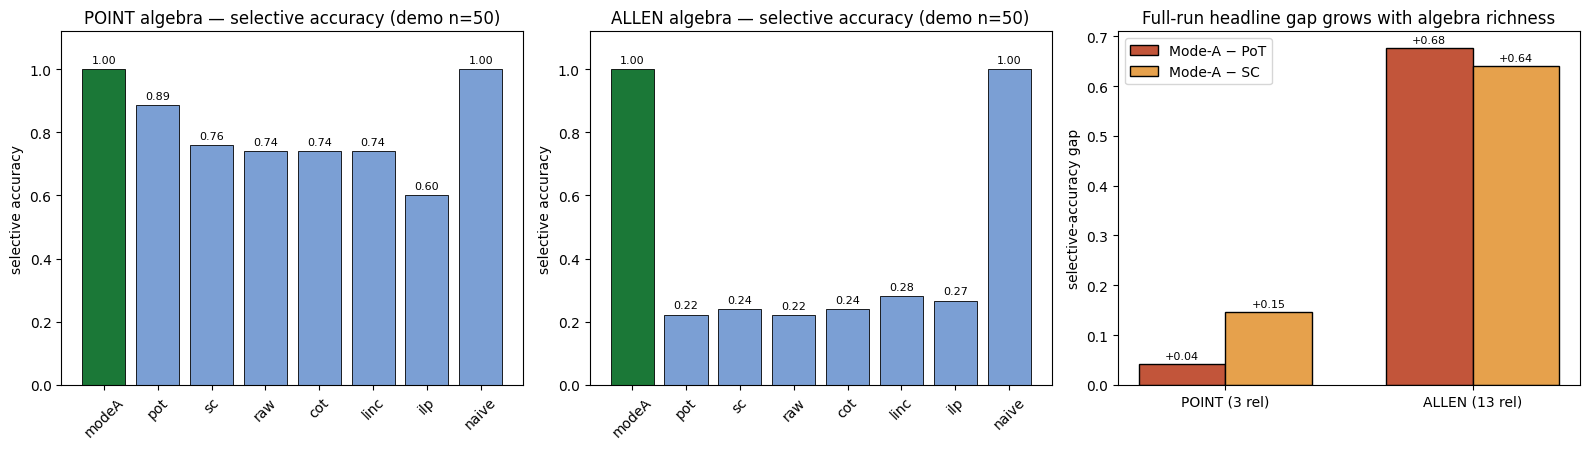

Central finding: the closure advantage over neural per-path reasoning scales with relation-algebra richness
(point gap small -> Allen gap large).


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))

bar_methods = ["modeA", "pot", "sc", "raw", "cot", "linc", "ilp", "naive"]
colors = ["#1b7837"] + ["#7b9fd4"] * (len(bar_methods) - 1)
for ax, alg in zip(axes[:2], ("point", "allen")):
    lb = results[alg]["leaderboard"]
    vals = [0.0 if lb[m]["selective_accuracy"] != lb[m]["selective_accuracy"]
            else lb[m]["selective_accuracy"] for m in bar_methods]
    ax.bar(bar_methods, vals, color=colors, edgecolor="black", linewidth=0.6)
    for i, m in enumerate(bar_methods):
        ax.text(i, vals[i] + 0.02, f"{vals[i]:.2f}", ha="center", fontsize=8)
    ax.set_title(f"{alg.upper()} algebra — selective accuracy (demo n={results[alg]['n']})")
    ax.set_ylim(0, 1.12); ax.set_ylabel("selective accuracy")
    ax.tick_params(axis="x", rotation=45)

ax = axes[2]
H = data["headline"]
gap_pot = [H["by_algebra"][a]["H1_bite_bearing_pool"]["leaderboard"]["pot"]["gap_vs_ref"]
           for a in ("point", "allen")]
gap_sc = [H["by_algebra"][a]["H1_bite_bearing_pool"]["leaderboard"]["sc"]["gap_vs_ref"]
          for a in ("point", "allen")]
x = np.arange(2); w = 0.35
ax.bar(x - w / 2, gap_pot, w, label="Mode-A − PoT", color="#c2553a", edgecolor="black")
ax.bar(x + w / 2, gap_sc, w, label="Mode-A − SC", color="#e6a14c", edgecolor="black")
for i in range(2):
    ax.text(i - w / 2, gap_pot[i] + 0.01, f"{gap_pot[i]:+.2f}", ha="center", fontsize=8)
    ax.text(i + w / 2, gap_sc[i] + 0.01, f"{gap_sc[i]:+.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(["POINT (3 rel)", "ALLEN (13 rel)"])
ax.set_title("Full-run headline gap grows with algebra richness")
ax.set_ylabel("selective-accuracy gap"); ax.legend(); ax.axhline(0, color="gray", lw=0.6)

plt.tight_layout()
plt.savefig("showdown.png", dpi=110, bbox_inches="tight")
plt.show()
print("Central finding: the closure advantage over neural per-path reasoning scales with "
      "relation-algebra richness\n(point gap small -> Allen gap large).")